# Important Parameter Separation

This notebook analyzes how benign vs malicious clients affect safety-critical parameters using safety-score based masks from wandg/snip-style artifacts.

The notebook stays minimal: load the saved score artifacts, build masks, and compare client updates against a harmful reference.

In [107]:
import math
import os
import pickle
import re

import numpy as np
import torch
from tqdm import tqdm

snip_attribution_paths = '/home/ps9044/safety-attribution/weietal/out49/llama2-7b-chat-hf/unstructured/wandg_weightonly'
utility_attribution_path = os.path.join(snip_attribution_paths, 'alpaca_cleaned_no_safety/wanda_score')
safety_attribution_path = os.path.join(snip_attribution_paths, 'align/wanda_score')

_LORA_PARAM_RE = re.compile(r'^base_model\.model\.model\.layers\.(\d+)\.(.+)\.lora_[AB]\.weight$')


def parse_lora_param_name(param_name):
    match = _LORA_PARAM_RE.match(param_name)
    if match is None:
        return None
    layer_idx = int(match.group(1))
    module_name = match.group(2)
    return layer_idx, module_name


def score_path_for_param(param_name, attribution_root):
    parsed = parse_lora_param_name(param_name)
    if parsed is None:
        return None
    layer_idx, module_name = parsed
    return os.path.join(
        attribution_root,
        f'W_metric_layer_{layer_idx}_name_model.layers.{layer_idx}.{module_name}_weight.pkl',
    )


def safety_score_path_for_param(param_name, attribution_root=safety_attribution_path):
    return score_path_for_param(param_name, attribution_root)


def utility_score_path_for_param(param_name, attribution_root=utility_attribution_path):
    return score_path_for_param(param_name, attribution_root)

In [112]:
def _bottom_fraction_mask(scores, bottom_fraction):
    scores = torch.as_tensor(scores).detach().cpu().float()
    flat = scores.abs().reshape(-1)
    if flat.numel() == 0:
        return torch.zeros_like(scores, dtype=torch.bool)
    keep = max(1, int(math.ceil(flat.numel() * float(bottom_fraction))))
    threshold = torch.topk(flat, keep, largest=False).values.max()
    return scores.abs() <= threshold


def _collect_lora_pairs(local_dict):
    grouped = {}
    for param_name, param in local_dict.items():
        if not torch.is_tensor(param):
            continue
        parsed = parse_lora_param_name(param_name)
        if parsed is None:
            continue
        layer_idx, module_name = parsed
        bucket = grouped.setdefault((layer_idx, module_name), {})
        if '.lora_A.weight' in param_name:
            bucket['A'] = param.detach().cpu().float()
        elif '.lora_B.weight' in param_name:
            bucket['B'] = param.detach().cpu().float()
    return grouped


def _ordered_lora_module_keys(local_dict):
    ordered = []
    seen = set()
    for param_name in local_dict:
        parsed = parse_lora_param_name(param_name)
        if parsed is None:
            continue
        if parsed in seen:
            continue
        seen.add(parsed)
        ordered.append(parsed)
    return ordered


def _mask_cache_path(cache_dir, mode, p, q):
    if cache_dir is None:
        return None
    os.makedirs(cache_dir, exist_ok=True)
    def _tag(value):
        text = f"{float(value):.6f}".rstrip('0').rstrip('.')
        return text.replace('.', 'p') if text else '0'
    return os.path.join(cache_dir, f'mask_cache_mode{mode}_p{_tag(p)}_q{_tag(q)}.pkl')


def precompute_score_masks(
    local_dict,
    safety_root,
    utility_root=None,
    p=0.1,
    q=None,
    mode=0,
    cache_dir=None,
    force=False,
):
    if q is None:
        q = p
    grouped = _collect_lora_pairs(local_dict)
    cache_path = _mask_cache_path(cache_dir, mode, p, q)
    meta = {
        'safety_root': safety_root,
        'utility_root': utility_root,
        'p': float(p),
        'q': float(q),
        'mode': int(mode),
    }
    if cache_path and not force and os.path.exists(cache_path):
        with open(cache_path, 'rb') as handle:
            payload = pickle.load(handle)
        if payload.get('meta') == meta:
            return payload.get('masks', {}), payload.get('missing_score_paths', [])

    masks = {}
    missing_score_paths = []
    print('collected all lora weights')
    print(f'Example: {list(grouped.keys())[0]}')
    print(grouped[list(grouped.keys())[0]].keys())

    for (layer_idx, module_name), pair in tqdm(sorted(grouped.items())):
        if 'A' not in pair or 'B' not in pair:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')
        delta_shape = (pair['B'].shape[0], pair['A'].shape[1])
        safety_path = safety_score_path_for_param(
            f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
            attribution_root=safety_root,
        )
        if safety_path is None or not os.path.exists(safety_path):
            missing_score_paths.append(safety_path)
            continue
        with open(safety_path, 'rb') as handle:
            safety_score = pickle.load(handle)
        safety_mask = _bottom_fraction_mask(safety_score, p)
        if safety_mask.shape != delta_shape:
            raise ValueError(
                f'mask shape mismatch for layer {layer_idx} {module_name}: '
                f'{tuple(safety_mask.shape)} vs {tuple(delta_shape)}',
            )

        utility_mask = None
        if mode == 1:
            if utility_root is None:
                raise ValueError('utility_root is required when mode=1')
            utility_path = utility_score_path_for_param(
                f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
                attribution_root=utility_root,
            )
            if utility_path is None or not os.path.exists(utility_path):
                missing_score_paths.append(utility_path)
                continue
            with open(utility_path, 'rb') as handle:
                utility_score = pickle.load(handle)
            utility_mask = _bottom_fraction_mask(utility_score, q)
            if utility_mask.shape != delta_shape:
                raise ValueError(
                    f'utility mask shape mismatch for layer {layer_idx} {module_name}: '
                    f'{tuple(utility_mask.shape)} vs {tuple(delta_shape)}',
                )
        masks[(layer_idx, module_name)] = {
            'safety': safety_mask,
            'utility': utility_mask,
        }

    if cache_path:
        payload = {
            'meta': meta,
            'masks': masks,
            'missing_score_paths': missing_score_paths,
        }
        with open(cache_path, 'wb') as handle:
            pickle.dump(payload, handle)
    return masks, missing_score_paths


def calculate_parameter_change(
    local_dict,
    safety_root,
    utility_root=None,
    p=0.1,
    q=None,
    mode=0,
    precomputed_masks=None,
    reference_data=None,
):
    """Compute masked delta-W norms for LoRA modules.

    mode=0: keep the smallest p-fraction of safety scores.
    mode=1: keep the smallest p-fraction of safety scores and remove the smallest q-fraction of utility scores.
    """
    if q is None:
        q = p

    grouped = _collect_lora_pairs(local_dict)
    ordered_keys = _ordered_lora_module_keys(local_dict)
    if len(ordered_keys) != len(grouped):
        ordered_keys = sorted(grouped.keys())
    if reference_data is None:
        raise ValueError('reference_data is required for cosine similarity')
    if len(reference_data) != len(ordered_keys):
        raise ValueError(
            f'reference_data length {len(reference_data)} does not match '
            f'lora module count {len(ordered_keys)}',
        )

    module_stats = []
    missing_score_paths = []

    for ref_idx, (layer_idx, module_name) in enumerate(ordered_keys):
        pair = grouped.get((layer_idx, module_name))
        if pair is None:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')
        if 'A' not in pair or 'B' not in pair:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')

        assert pair['B'].shape[1] < 50
        delta_w = pair['B'] @ pair['A']
        mask = torch.ones_like(delta_w, dtype=torch.bool)
        
        safety_path = None
        utility_path = None
        # mask_entry = None
        # if precomputed_masks is not None:
        #     mask_entry = precomputed_masks.get((layer_idx, module_name))


        # if mask_entry is not None:
        #     safety_mask = mask_entry['safety']
        #     utility_mask = mask_entry.get('utility')
        # else:
        #     safety_path = safety_score_path_for_param(
        #         f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
        #         attribution_root=safety_root,
        #     )
        #     if safety_path is None or not os.path.exists(safety_path):
        #         missing_score_paths.append(safety_path)
        #         continue
        #     with open(safety_path, 'rb') as handle:
        #         safety_score = pickle.load(handle)
        #     safety_mask = _bottom_fraction_mask(safety_score, p)
        #     utility_mask = None
        #     if mode == 1:
        #         if utility_root is None:
        #             raise ValueError('utility_root is required when mode=1')
        #         utility_path = utility_score_path_for_param(
        #             f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
        #             attribution_root=utility_root,
        #         )
        #         if utility_path is None or not os.path.exists(utility_path):
        #             missing_score_paths.append(utility_path)
        #             continue
        #         with open(utility_path, 'rb') as handle:
        #             utility_score = pickle.load(handle)
        #         utility_mask = _bottom_fraction_mask(utility_score, q)

        # if safety_mask.shape != delta_w.shape:
        #     raise ValueError(
        #         f'mask shape mismatch for layer {layer_idx} {module_name}: '
        #         f'{tuple(safety_mask.shape)} vs {tuple(delta_w.shape)}',
        #     )

        # mask = safety_mask
        # if mode == 1:
        #     if utility_mask is None:
        #         raise ValueError(f'utility mask missing for layer {layer_idx} {module_name}')
        #     if utility_mask.shape != delta_w.shape:
        #         raise ValueError(
        #             f'utility mask shape mismatch for layer {layer_idx} {module_name}: '
        #             f'{tuple(utility_mask.shape)} vs {tuple(delta_w.shape)}',
        #         )
        #     mask = safety_mask & (~utility_mask)

        masked_delta = delta_w[mask]
        reference_vec = reference_data[ref_idx]
        cosine_sim = torch.nn.functional.cosine_similarity(
            masked_delta.flatten(),
            -reference_vec.flatten(),
            dim=0,
        ) 

        module_stats.append(
            {
                'layer_idx': layer_idx,
                'module_name': module_name,
                'safety_score_path': safety_path,
                'utility_score_path': utility_path,
                'masked_l2': float(torch.linalg.norm(masked_delta).item()),
                'cosine_sim': float(cosine_sim.item()),
                'masked_l1_mean': float(masked_delta.abs().mean().item()) if masked_delta.numel() else 0.0,
                'masked_numel': int(masked_delta.numel()),
                'total_numel': int(delta_w.numel()),
            }
        )

    return {
        'n_lora_modules': int(len(grouped)),
        'n_scored_modules': int(len(module_stats)),
        'total_masked_l2': float(sum(item['masked_l2'] for item in module_stats)),
        'mean_masked_l1': float(np.mean([item['masked_l1_mean'] for item in module_stats])) if module_stats else 0.0,
        'module_stats': module_stats,
        'missing_score_paths': missing_score_paths,
        'cosine_sim_sum': float(np.sum([item['cosine_sim'] for item in module_stats])) if module_stats else 0.0,
    }

In [121]:
example_param_name = 'base_model.model.model.layers.0.self_attn.q_proj.lora_A.weight'
print(safety_score_path_for_param(example_param_name))

run_save = '/scratch/ps9044/newsetting/BeaverTailsSafe5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260517123537'
sparsity = 1.0
mask_mode = 0  # 0 = safety only, 1 = safety minus utility
benign_clients = {0, 1, 2, 3, 4}
roundwise_param_changes = []
mask_cache_dir = os.path.join(run_save, 'mask_cache') if run_save else None
precomputed_masks = None
mask_cache_missing = []
# reference_path = '/home/ps9044/RPA/fedllm-attack/delta_matrix_purebad10rounds_harmful_torch.float32.pkl'
reference_path = '/home/ps9044/delta_matrix_safelora_torch.float32_harmful_systemprompt.pkl'

key = 'cosine_sim_sum'
# key = 'total_masked_l2'
with open(reference_path, 'rb') as f:
    reference_data = pickle.load(f)

if run_save:
    for round_idx in tqdm(range(1, 31)):
        round_path = os.path.join(run_save, f'round_{round_idx}.pkl')
        if not os.path.exists(round_path):
            continue
        with open(round_path, 'rb') as f:
            data = pickle.load(f)
        # if precomputed_masks is None:
        #     seed_client = data['clients'][0]
        #     precomputed_masks, mask_cache_missing = precompute_score_masks(
        #         data['local_dict_list'][seed_client],
        #         safety_root=safety_attribution_path,
        #         utility_root=utility_attribution_path,
        #         p=sparsity,
        #         q=sparsity,
        #         mode=mask_mode,
        #         cache_dir=mask_cache_dir,
        #     )
        round_param_changes = []
        for client in data['clients']:
            summary = calculate_parameter_change(
                data['local_dict_list'][client],
                safety_root=safety_attribution_path,
                utility_root=utility_attribution_path,
                p=sparsity,
                q=sparsity,
                mode=mask_mode,
                precomputed_masks=precomputed_masks,
                reference_data=reference_data
            )
            summary['client'] = client
            summary['group'] = 'benign' if client in benign_clients else 'malicious'
            round_param_changes.append(summary)
            print(f'Client {client} | {key}: {summary[key]}')
        roundwise_param_changes.append(round_param_changes)

preview = None
if roundwise_param_changes and roundwise_param_changes[0]:
    first = roundwise_param_changes[0][0]
    preview = {
        'client': first['client'],
        'group': first['group'],
        'n_lora_modules': first['n_lora_modules'],
        'n_scored_modules': first['n_scored_modules'],
        'total_masked_l2': first['total_masked_l2'],
        'mean_masked_l1': first['mean_masked_l1'],
        'missing_score_paths': len(first['missing_score_paths']),
        'cosine_sim_sum': first['cosine_sim_sum'],
    }

print({
    'rounds_loaded': len(roundwise_param_changes),
    'preview': preview,
    'mask_cache_missing': len(mask_cache_missing),
})

/home/ps9044/safety-attribution/weietal/out49/llama2-7b-chat-hf/unstructured/wandg_weightonly/align/wanda_score/W_metric_layer_0_name_model.layers.0.self_attn.q_proj_weight.pkl


  0%|          | 0/30 [00:00<?, ?it/s]

Client 0 | cosine_sim_sum: 0.775372487551067
Client 1 | cosine_sim_sum: 0.615951711544767
Client 2 | cosine_sim_sum: 0.8443415182409808
Client 3 | cosine_sim_sum: 0.8164566995110363
Client 4 | cosine_sim_sum: 0.8279541037045419
Client 5 | cosine_sim_sum: 0.8737477420218056
Client 6 | cosine_sim_sum: 0.8681589859043015
Client 7 | cosine_sim_sum: 0.841419794014655
Client 8 | cosine_sim_sum: 0.8695912915281951


  3%|▎         | 1/30 [00:40<19:22, 40.07s/it]

Client 9 | cosine_sim_sum: 0.8682862655841745
Client 0 | cosine_sim_sum: 2.0746408228296787
Client 1 | cosine_sim_sum: 1.854625216103159
Client 2 | cosine_sim_sum: 2.1331059555523098
Client 3 | cosine_sim_sum: 2.1503492072224617
Client 4 | cosine_sim_sum: 2.143298350740224
Client 5 | cosine_sim_sum: 2.1630350567866117
Client 6 | cosine_sim_sum: 2.1707684870343655
Client 7 | cosine_sim_sum: 2.1676336508244276
Client 8 | cosine_sim_sum: 2.2136233476921916


...

Client 9 | cosine_sim_sum: 5.251914088614285
Client 0 | cosine_sim_sum: 5.249515137635171
Client 1 | cosine_sim_sum: 5.25129958242178
Client 2 | cosine_sim_sum: 5.249871518462896
Client 3 | cosine_sim_sum: 5.247775613795966
Client 4 | cosine_sim_sum: 5.24842419475317
Client 5 | cosine_sim_sum: 5.2526821102947
Client 6 | cosine_sim_sum: 5.253574352245778
Client 7 | cosine_sim_sum: 5.252905493602157
Client 8 | cosine_sim_sum: 5.252435117959976


 97%|█████████▋| 29/30 [21:23<01:12, 72.34s/it]

Client 9 | cosine_sim_sum: 5.252612465526909
Client 0 | cosine_sim_sum: 5.2498150379396975
Client 1 | cosine_sim_sum: 5.251601975411177
Client 2 | cosine_sim_sum: 5.2498330171220005
Client 3 | cosine_sim_sum: 5.250847614835948
Client 4 | cosine_sim_sum: 5.2497231010347605
Client 5 | cosine_sim_sum: 5.25362856965512
Client 6 | cosine_sim_sum: 5.252094541210681
Client 7 | cosine_sim_sum: 5.252566795330495
Client 8 | cosine_sim_sum: 5.251364845316857


100%|██████████| 30/30 [22:06<00:00, 44.20s/it]

Client 9 | cosine_sim_sum: 5.2530436725355685
{'rounds_loaded': 30, 'preview': {'client': 0, 'group': 'benign', 'n_lora_modules': 64, 'n_scored_modules': 64, 'total_masked_l2': 4.421478975564241, 'mean_masked_l1': 1.3174286095818388e-05, 'missing_score_paths': 0, 'cosine_sim_sum': 0.775372487551067}, 'mask_cache_missing': 0}


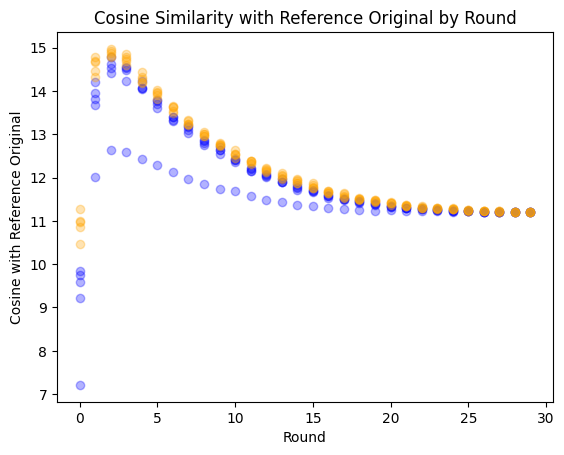

In [115]:
# plot 
import matplotlib.pyplot as plt
benigns = [0, 1, 2, 3, 4]

for client in range(10):
    round_datas = []
    for round, round_data in enumerate(roundwise_param_changes):
        for client_data in round_data:
            if client_data['client'] == client:
                round_datas.append(client_data['total_masked_l2'])
                break
        # print(round_datas)
        if client in benigns:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (benign)', marker='o', color='blue', alpha=0.3)
        else:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (malicious)', marker='o', color='orange', alpha=0.3)

        
plt.xlabel('Round')
# plt.ylabel('Total Masked L2 Change')
# plt.title('Total Masked L2 Change by Round')
plt.ylabel('Cosine with Reference Original')
plt.title('Cosine Similarity with Reference Original by Round')
plt.show()


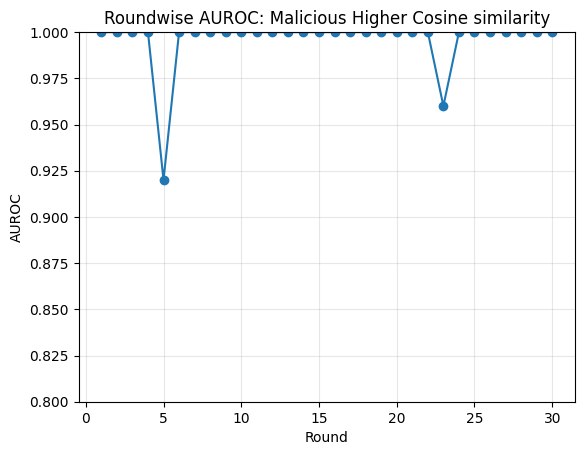

In [118]:
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

roundwise_aurocs = []

for round_idx, round_data in enumerate(roundwise_param_changes, start=1):
    y_true = []
    y_score = []

    for client_data in round_data:
        client = client_data['client']

        # malicious = 1, benign = 0
        y_true.append(0 if client in benign_clients else 1)

        # higher L2 means more malicious
        y_score.append(client_data[key])

    if len(set(y_true)) == 2:
        auroc = roc_auc_score(y_true, y_score)
    else:
        auroc = np.nan

    roundwise_aurocs.append(auroc)

plt.figure()
plt.plot(
    range(1, len(roundwise_aurocs) + 1),
    roundwise_aurocs,
    marker='o'
)
plt.xlabel('Round')
plt.ylabel('AUROC')
plt.title('Roundwise AUROC: Malicious Higher Cosine similarity')
plt.ylim(0.8, 1)
plt.grid(True, alpha=0.3)
plt.show()

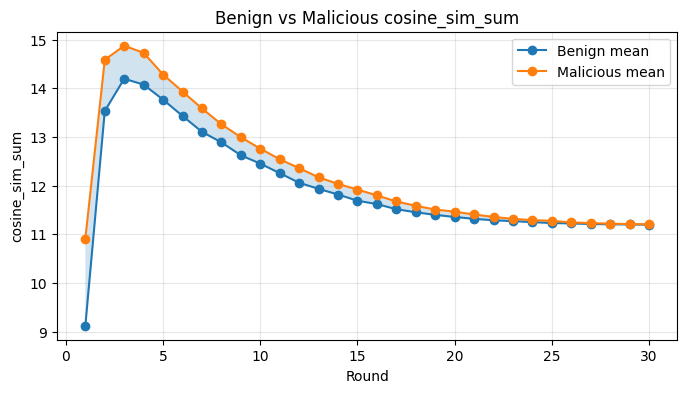

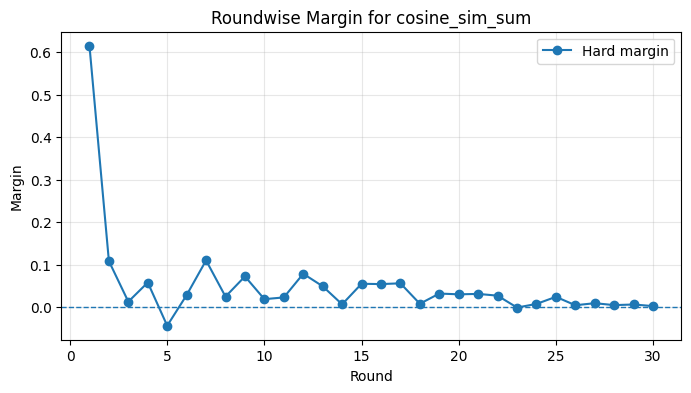

In [120]:
import numpy as np
import matplotlib.pyplot as plt

rounds = []
benign_means = []
mal_means = []
mean_margins = []
hard_margins = []

for r, round_data in enumerate(roundwise_param_changes, start=1):
    benign_scores = []
    mal_scores = []

    for client_data in round_data:
        score = client_data[key]

        if client_data["client"] in benign_clients:
            benign_scores.append(score)
        else:
            mal_scores.append(score)

    if len(benign_scores) == 0 or len(mal_scores) == 0:
        continue

    benign_scores = np.array(benign_scores)
    mal_scores = np.array(mal_scores)

    rounds.append(r)
    benign_means.append(benign_scores.mean())
    mal_means.append(mal_scores.mean())

    mean_margins.append(mal_scores.mean() - benign_scores.mean())
    hard_margins.append(mal_scores.min() - benign_scores.max())

plt.figure(figsize=(8, 4))
plt.plot(rounds, benign_means, marker="o", label="Benign mean")
plt.plot(rounds, mal_means, marker="o", label="Malicious mean")
plt.fill_between(rounds, benign_means, mal_means, alpha=0.2)
plt.xlabel("Round")
plt.ylabel(key)
plt.title(f"Benign vs Malicious {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
# plt.plot(rounds, mean_margins, marker="o", label="Mean margin")
plt.plot(rounds, hard_margins, marker="o", label="Hard margin")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Round")
plt.ylabel("Margin")
plt.title(f"Roundwise Margin for {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()